<a href="https://colab.research.google.com/github/oliviergentil/MAR_Explorer/blob/main/exemple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!python -m pip install \
    --index-url https://test.pypi.org/simple/ \
    --extra-index-url https://pypi.org/simple/ \
    mar-explorer

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/


In [85]:
import requests
import matplotlib.pyplot as plt
import pandas as pd


url = "https://raw.githubusercontent.com/oliviergentil/MAR_Explorer/main/mar.json"

response = requests.get(url)
response.raise_for_status()

data = response.json()

In [86]:
mar.list_tables(years=[2025, 2024, 2023], keyword="exhaustion")


=== 2025 ===

  Chapter 2:
    26. Table 26: Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits by province or territory, gender, age and claimant category, Canada, 2023-24 and 2024-25
    27. Table 27: Completed claims for Employment Insurance regular benefits by exhaustion type and characteristics, Canada, 2024-25

=== 2024 ===

  Chapter 2:
    25. Table 25 – Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits by province or territory, gender, age and claimant category, Canada, 2022‑23 to 2023‑24*
    26. Table 26 – Completed claims for Employment Insurance regular benefits by exhaustion type and characteristics, Canada, 2023‑24*

=== 2023 ===

  Chapter 2:
    30. Table 30 – Entitlement and benefit period exhaustion rates of completed claims for Employment Insurance regular benefits established between September 27, 2020 and September 25, 2021 by province or territo

In [87]:
exhaustion_2023 = mar.table(2023, 2, 30)
exhaustion_2024 = mar.table(2024, 2, 25)

exhaustion = exhaustion_2023.data.merge(
    exhaustion_2024.data,
    on="Category"
)
exhaustion

,Category,Entitlement exhaustion rateP,Benefit period exhaustion rateP,Entitlement exhaustion rate 2022‑23,Entitlement exhaustion rate 2023‑24P,Change in entitlement exhaustion rate (% points),Benefit period exhaustion rate 2022‑23,Benefit period exhaustion rate 2023‑24P,Change in benefit period exhaustion rate (% points)
0,Newfoundland and Labrador,45.9%,39.3%,34.5%R,40.6%,6.1,39.4%R,36.4%,-3.1
1,Prince Edward Island,32.6%,30.7%,40.8%R,43.0%,2.2,25.6%,26.8%,1.2
2,Nova Scotia,47.7%,33.3%,43.4%R,44.1%,0.7,21.8%R,22.7%,0.9
3,New Brunswick,32.6%,33.7%,37.3%,41.7%,4.4,32.5%R,30.5%,-2.1
4,Quebec,34.9%,44.3%,34.1%R,30.0%,-4.1,18.4%R,23.8%,5.4
5,Ontario,42.7%,36.6%,35.7%R,33.8%,-1.9,11.7%R,16.0%,4.3
6,Manitoba,45.0%,35.7%,38.9%,35.4%,-3.5,12.9%R,19.2%,6.2
7,Saskatchewan,49.5%,28.9%,36.5%R,36.8%,0.4,15.4%R,19.2%,3.7
8,Alberta,44.0%,36.1%,38.6%R,36.1%,-2.5,11.2%R,16.0%,4.8
9,British Columbia,34.0%,45.4%,38.6%R,36.0%,-2.6,10.8%R,14.2%,3.4


In [88]:
for x, y in enumerate(exhaustion.columns):
    print(x, y)

0 Category
1 Entitlement exhaustion rateP
2 Benefit period exhaustion rateP
3 Entitlement exhaustion rate 2022‑23
4 Entitlement exhaustion rate 2023‑24P
5 Change in entitlement exhaustion rate (% points)
6 Benefit period exhaustion rate 2022‑23
7 Benefit period exhaustion rate 2023‑24P
8 Change in benefit period exhaustion rate (% points)


In [89]:
exhaustion = exhaustion.iloc[:, [0, 1, 2, 3, 4, 6, 7]]

In [90]:
exhaustion = exhaustion.replace("R", "", regex=True)

In [91]:
exhaustion

,Category,Entitlement exhaustion rateP,Benefit period exhaustion rateP,Entitlement exhaustion rate 2022‑23,Entitlement exhaustion rate 2023‑24P,Benefit period exhaustion rate 2022‑23,Benefit period exhaustion rate 2023‑24P
0,Newfoundland and Labrador,45.9%,39.3%,34.5%,40.6%,39.4%,36.4%
1,Prince Edward Island,32.6%,30.7%,40.8%,43.0%,25.6%,26.8%
2,Nova Scotia,47.7%,33.3%,43.4%,44.1%,21.8%,22.7%
3,New Brunswick,32.6%,33.7%,37.3%,41.7%,32.5%,30.5%
4,Quebec,34.9%,44.3%,34.1%,30.0%,18.4%,23.8%
5,Ontario,42.7%,36.6%,35.7%,33.8%,11.7%,16.0%
6,Manitoba,45.0%,35.7%,38.9%,35.4%,12.9%,19.2%
7,Saskatchewan,49.5%,28.9%,36.5%,36.8%,15.4%,19.2%
8,Alberta,44.0%,36.1%,38.6%,36.1%,11.2%,16.0%
9,British Columbia,34.0%,45.4%,38.6%,36.0%,10.8%,14.2%


In [94]:
for col in exhaustion.columns[1:]:
    exhaustion[col] = (
        exhaustion[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

In [95]:
print(exhaustion.dtypes)

Category                                    object
Entitlement exhaustion rateP               float64
Benefit period exhaustion rateP            float64
Entitlement exhaustion rate 2022‑23        float64
Entitlement exhaustion rate 2023‑24P       float64
Benefit period exhaustion rate 2022‑23     float64
Benefit period exhaustion rate 2023‑24P    float64
dtype: object


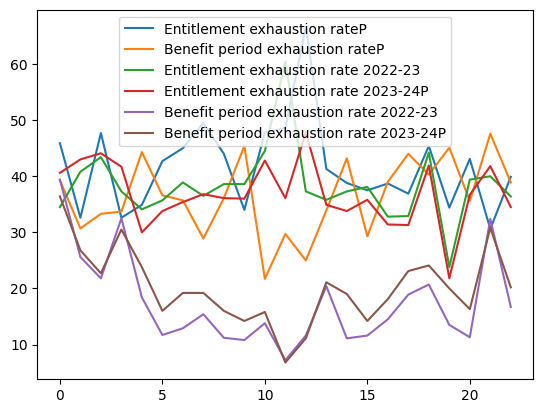

In [96]:
exhaustion.plot()
plt.show()

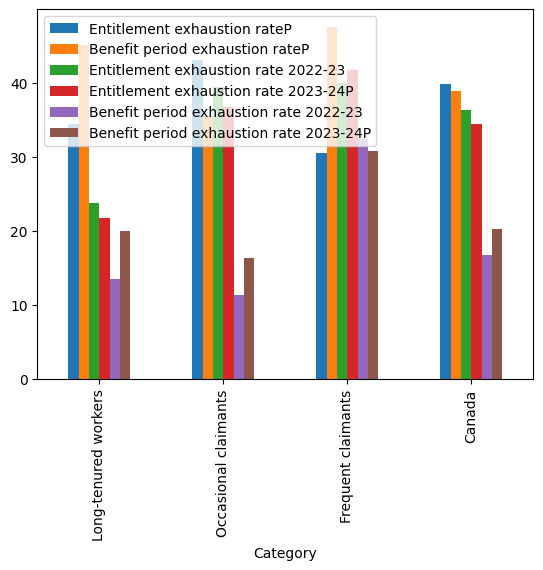

In [109]:
exhaustion.iloc[19:].plot(
    x="Category",
    kind="bar",
)

plt.show()